In [1]:
%reload_ext autoreload
%autoreload 2

# get the dataset first

In [2]:
import sys
sys.path.append('/rhome/sawale/indus_traning/mlm-fine-tuning/mlm')

In [3]:
import pandas as pd
data = pd.read_csv("../data/cleaned_production_dump.csv")

In [4]:
data.info(), data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558091 entries, 0 to 558090
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           558091 non-null  object
 1   url1         475632 non-null  object
 2   title        558089 non-null  object
 3   collection   558091 non-null  object
 4   treepath     558091 non-null  object
 5   sourcestr56  557375 non-null  object
 6   text         558089 non-null  object
 7   sourcebool3  558091 non-null  bool  
dtypes: bool(1), object(7)
memory usage: 30.3+ MB


(None, (558091, 8))

In [5]:
# Assuming df is your DataFrame
nan_counts = data.isna().sum()
print(nan_counts)

id                 0
url1           82459
title              2
collection         0
treepath           0
sourcestr56      716
text               2
sourcebool3        0
dtype: int64


# Filter 1

In [6]:
import re

data = data[data['text'] != ""]

data["text"] = data.apply(lambda x: str(x["text"]).strip(), axis=1)

data = data.drop_duplicates(subset=['text'])

data["text"] = data["text"].str.replace(r"\\n", "\n", regex=True)
data["line"] = data["text"].apply(lambda x: x.split("\n") if isinstance(x, str) else [])



data["word_counts"] = data.apply(lambda x: [len([w for w in l.split(" ") if w != ""]) for l in x["line"]], axis=1)

data.shape

(547029, 10)

In [7]:
data.head()

,id,url1,title,collection,treepath,sourcestr56,text,sourcebool3,line,word_counts
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Data,ACTIVATE: Data - NASA Langley Research Center ...,False,[ACTIVATE: Data - NASA Langley Research Center...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 3, 0, 2, 0, 4, ..."
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Home - NASA Langley Research Center ...,False,[ACTIVATE: Home - NASA Langley Research Center...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 2, 0, 61, 0, 65..."
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Media - NASA Langley Research Center...,False,[ACTIVATE: Media - NASA Langley Research Cente...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 3, 0, 2, 0, 3, ..."
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Missions and Instruments,ACTIVATE: Instruments - NASA Langley Research ...,False,[ACTIVATE: Instruments - NASA Langley Research...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 2, 0, 123, 0, 7..."
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Education - NASA Langley Research Ce...,False,[ACTIVATE: Education - NASA Langley Research C...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 2, 0, 2, 0, 14,..."


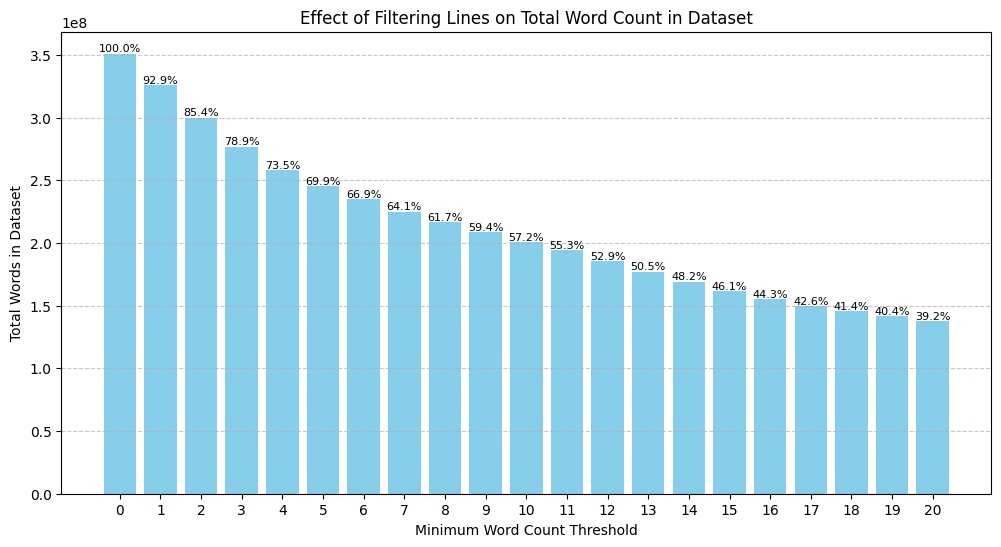

In [8]:

import pandas as pd
import matplotlib.pyplot as plt

exploded_data = data.explode("line")
exploded_data["n_words"] = exploded_data["line"].apply(lambda x: len([i for i in x.split(" ") if i != ""]))


# Assuming `exploded_data` is already defined
word_counts = []
total_words = exploded_data["n_words"].sum()  # Total words before any filtering
percentages = []

for threshold in range(21):
    filtered_data = exploded_data[exploded_data["n_words"] > threshold]
    filtered_word_count = filtered_data["n_words"].sum()
    word_counts.append(filtered_word_count)
    percentages.append((filtered_word_count / total_words) * 100)  # Compute percentage

# Plot the results as a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(range(21), word_counts, color='skyblue')

plt.xlabel("Minimum Word Count Threshold")
plt.ylabel("Total Words in Dataset")
plt.title("Effect of Filtering Lines on Total Word Count in Dataset")
plt.xticks(range(21))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar with the percentage of words remaining
for bar, percent in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{percent:.1f}%", 
             ha='center', va='bottom', fontsize=8)

plt.show()

# Genrating new filtered data

In [9]:
def gen_new_text(row, threshold=2):
    new_text = ""
    lines = row["line"]
    word_counts = row["word_counts"]

    for l, wc in zip(lines, word_counts):
        if wc > threshold:
            new_text += l + "\n"
    return new_text

data["new_text"] = data.apply(lambda x: gen_new_text(x, threshold=2), axis=1)
# update rename text columns
data = data.rename(columns={"text": "old_text", "new_text": "text"})

In [10]:
data.head()

,id,url1,title,collection,treepath,sourcestr56,old_text,sourcebool3,line,word_counts,text
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Data,ACTIVATE: Data - NASA Langley Research Center ...,False,[ACTIVATE: Data - NASA Langley Research Center...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 3, 0, 2, 0, 4, ...",ACTIVATE: Data - NASA Langley Research Center ...
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Home - NASA Langley Research Center ...,False,[ACTIVATE: Home - NASA Langley Research Center...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 2, 0, 61, 0, 65...",ACTIVATE: Home - NASA Langley Research Center ...
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Media - NASA Langley Research Center...,False,[ACTIVATE: Media - NASA Langley Research Cente...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 3, 0, 2, 0, 3, ...",ACTIVATE: Media - NASA Langley Research Center...
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Missions and Instruments,ACTIVATE: Instruments - NASA Langley Research ...,False,[ACTIVATE: Instruments - NASA Langley Research...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 2, 0, 123, 0, 7...",ACTIVATE: Instruments - NASA Langley Research ...
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Education - NASA Langley Research Ce...,False,[ACTIVATE: Education - NASA Langley Research C...,"[9, 0, 4, 0, 6, 0, 1, 0, 1, 0, 2, 0, 2, 0, 14,...",ACTIVATE: Education - NASA Langley Research Ce...


In [11]:
data["text"] = data.apply(lambda x: str(x["text"]).strip(), axis=1)
data = data[data['text'] != ""]
data = data.drop_duplicates(subset=['text'])

data.shape

(545644, 11)

In [ ]:
data.drop(["line", "word_counts"], axis=1, inplace=True)
data.to_parquet("../data/cleaned_prod_dump_filtered_word_count.parquet", index=False)

In [16]:
data = pd.read_parquet("../data/cleaned_prod_dump_filtered_word_count.parquet")

ArrowNotImplementedError: Nested data conversions not implemented for chunked array outputs

# generating YAKE importance keywords

In [14]:
from generate_keyword import gen_YAKE_keyword
n_rows = 100
path = "../data/cleaned_prod_dump_filtered_word_count.parquet"
df = gen_YAKE_keyword(path, "text", n_rows)

ArrowNotImplementedError: Nested data conversions not implemented for chunked array outputs